In [ ]:
# IMPORTS PARA TODO EL NOTEBOOK
import numpy as np
from scipy.io import wavfile
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy import signal
from PIL import Image
from matplotlib.pyplot import imshow
# Funciones auxiliares
def plot_frec(x,fs,fmax,m):
  puntos = int(fmax/fs*m)
  lx = len(x)
  nt = (lx + m - 1)//m
  xp = np.append(x,np.zeros(-lx+nt*m))
  xmw = np.reshape( xp, (m,nt), order='F')
  xmf = np.fft.fft(xmw,len(xmw),axis=0)/m
  xf = np.linspace(0, int(fs/2.0), int(m/2))
  plt.figure(figsize=(10,6))
  plt.title('Análisis en frecuencia',loc='center')
  plt.yscale("log")
  plt.plot(xf[0:puntos],np.abs(xmf[0:int(m/2),0:int(lx/m-1)]).mean(1)[0:puntos])
  plt.show()
def filtro_pasabajo(x,f_corte,fs):
	taps = signal.firwin(151,f_corte,nyq=fs/2.0)
	filtered_x = signal.lfilter(taps, 1.0, x)
	return(filtered_x)
def filtro_pasabanda(x,f_corte1,f_corte2,fs):
  taps = signal.firwin(151, [f_corte1, f_corte2], pass_zero=False,nyq=fs/2.0)
  filtered_x = signal.lfilter(taps, 1.0, x)
  return(filtered_x)
def obtener_muestras_comienzo_sync(signal, sync):
    peaks_corr = [(0, 0)]
    mindistance = 2000
    signalshifted = [x-128 for x in signal]
    sync = [x-128 for x in sync]
    for i in range(0,len(signalshifted) - len(sync)):
        corr = np.dot(sync, signalshifted[i : i+len(sync)])
        if i - peaks_corr[-1][0] > mindistance:
            peaks_corr.append((i, corr))
        elif corr > peaks_corr[-1][1]:
            peaks_corr[-1] = (i, corr)
    peaks = [i[0] for i in peaks_corr] # retrieve peak indexes from peaks_corr
    return peaks
def obtener_indices_comienzo_telemetria_con_similitud(telemetry, sync_telemetry):
  peaks_corr = [(0, 0)]
  mindistance = 8*16 - 3
  signalshifted = [x-128 for x in telemetry]
  sync = [x-128 for x in sync_telemetry]
  for i in range(0,len(signalshifted) - len(sync)):
      corr = np.dot(sync, signalshifted[i : i+len(sync)])
      if i - peaks_corr[-1][0] > mindistance:
          peaks_corr.append((i, corr))
      elif corr > peaks_corr[-1][1]:
          peaks_corr[-1] = (i, corr)
  peaks = [i[0] for i in peaks_corr] # retrieve peak indexes from peaks_corr
  corr = [i[1] for i in peaks_corr] # retrieve peak indexes from peaks_corr
  return peaks,corr
def visualizar_imagen(matriz_APT):
  img = Image.fromarray(matriz_APT)
  if img.mode != 'RGB':
      img = img.convert('RGB')
  plt.figure()
  plt.rcParams["figure.figsize"] = (14,14)
  plt.axis('off')
  plt.imshow(img,interpolation='none')
def guardar_imagen(matriz_APT, filename):
  img = Image.fromarray(matriz_APT)
  if img.mode != 'RGB':
      img = img.convert('RGB')
  img.save(filename)
def visualizar_histograma(x):
  plt.figure(figsize=(14,7))
  plt.hist(x,range(255))
  plt.ylabel('Frecuencia')
  plt.xlabel('Nivel de gris ( Blanco = 255, Negro = 0)')
  plt.title('Histograma')
  plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3,00baseband_137100000Hz_22-19-02_19-06-2024_Audio Denoise.mp3 to 3,00baseband_137100000Hz_22-19-02_19-06-2024_Audio Denoise.mp3






> El codigo comentado es para utilizacion del notebook con otra grabación


In [ ]:
filename =  '3,00baseband_137100000Hz_22-19-02_19-06-2024.wav'
fs, data = wavfile.read(filename)

data = np.array(data).astype(float)

In [ ]:
audio_cortado = data[:fs*20]                          #) Cortamos el audio para aligerar el procesado

Se intento pasar la señal por un filtro pasa bajo para bajar el ruido, pero aun asi sin resultados

In [ ]:
 datas = filtro_pasabajo(audio_cortado,5000,fs)

 resampleo = signal.resample_poly(datas, 1, 25)
 fs=10000

<ipython-input-12-0544dcc0768b>:24: DeprecationWarning: Keyword argument 'nyq' is deprecated in favour of 'fs' and will be removed in SciPy 1.12.0.
  taps = signal.firwin(151,f_corte,nyq=fs/2.0)


In [ ]:
 i = resampleo[:,0]
 q = resampleo[:,1]



> El primer paso es demodular en FM, en el informe anterior de explica el codigo. Se demodula en FM ya que es asi como transmiten los satelites NOAA, en el mayor de los casos se espera un ancho de banda de aproximadamente 50kHz, esto se debe a que el ancho de banda antes de modular en FM se multiplica en un rango de (2~10).


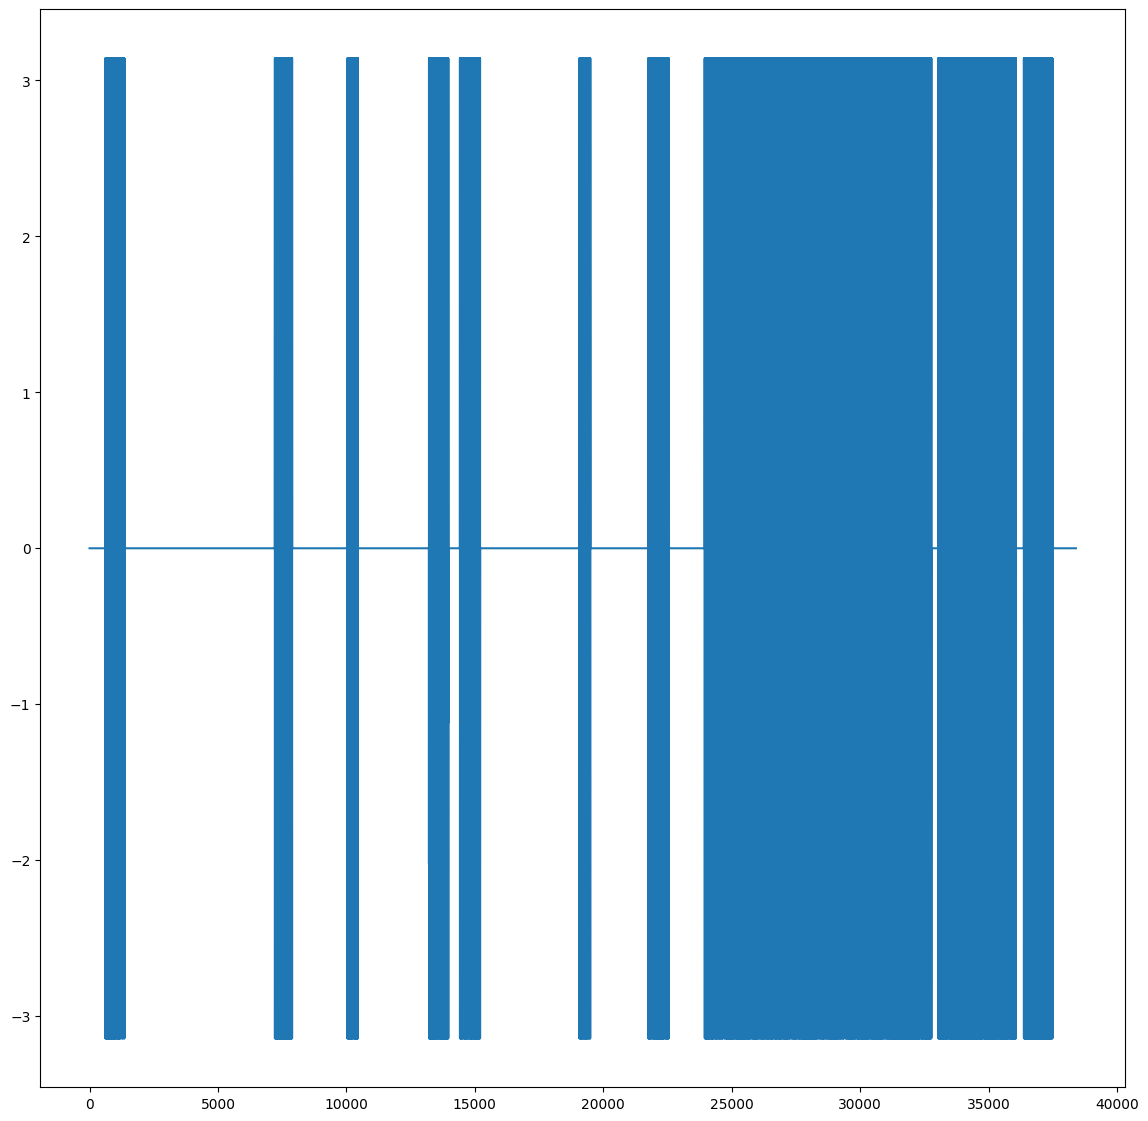

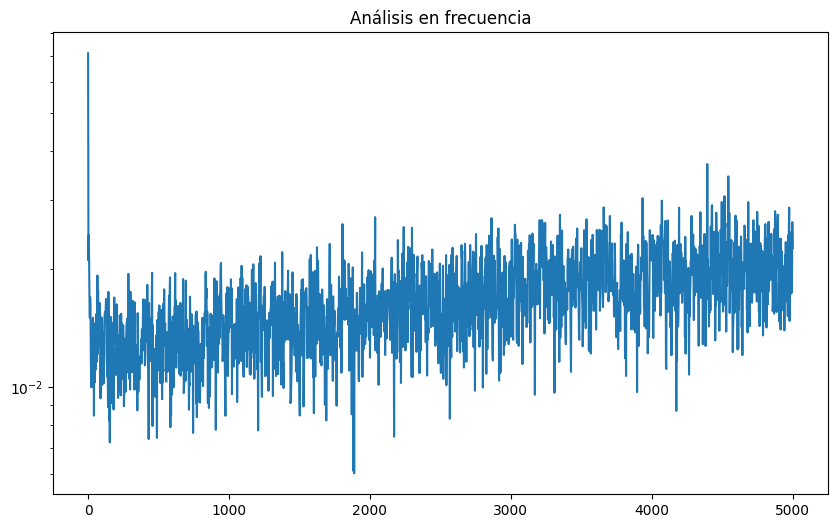

In [ ]:
# Demodular FM

fi = np.arctan2(q,i)             #) Funcion artan2, la explicacion respecto a su uso se encuentra en el informe, esta recibe los vectores que teoricamente al dividirlos son iguales a la tangente, por este motivo esd que se busca su inversa, el arctan, para obtener fi
uw =  np.unwrap(fi)              #) Funcion de NumPy Unwrap, la explicacion respecto a su uso se encuentra en el informe, esta recibe el arctan2 de q e i.

senial = np.zeros((len(uw)))     #) Se crea un vector de ceros del tamaño de nuestro audio

for k in range(1, len(uw)):      #) Se crea un bucle for que recorre el largo de nuestro audio sin contar su primer elemento(O) (en la teoria esto es la derivada)
  senial[k] = uw[k]-uw[k-1]      #) Recorre nuestro vector haciendo dicha diferencia.

# Analisis en tiempo
plt.plot(senial)
plt.show()

# Analisis en Frecuencia
plot_frec(senial,fs,10000,4096) #) Graficamos para observar


La señal demodulada se trata de una señal AM, por lo tanto el ancho de banda esperado es de 4480 Hz aproximadamente, el cual concuerda con lo observado en la grafica.



> El segundo paso es demodular en AM, se utilizo la siguiente relación trigonometrica:

$$\cos^2(\theta) = \frac{1 + \cos(2\theta)}{2}$$



<ipython-input-12-0544dcc0768b>:24: DeprecationWarning: Keyword argument 'nyq' is deprecated in favour of 'fs' and will be removed in SciPy 1.12.0.
  taps = signal.firwin(151,f_corte,nyq=fs/2.0)


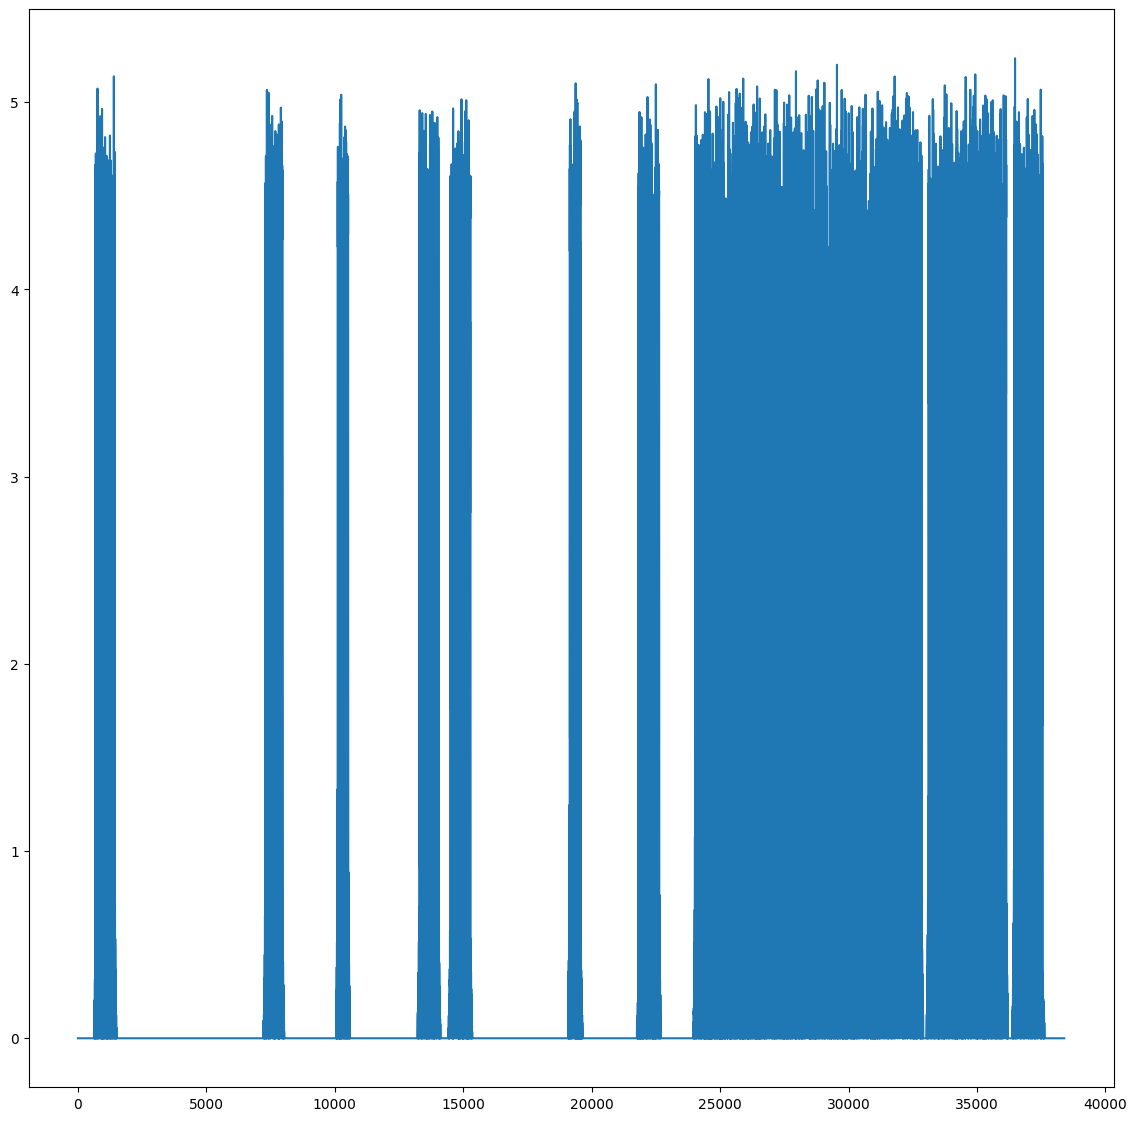

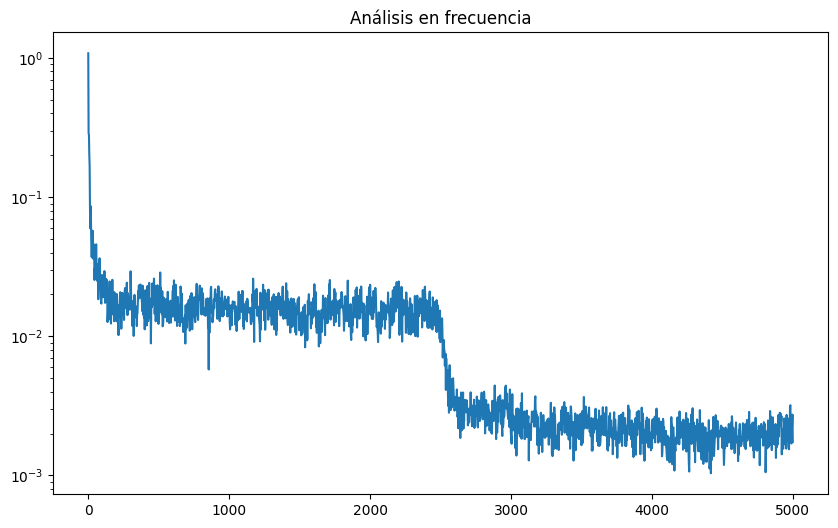

In [ ]:
# Demodular AM

t=np.array(len(senial))                      #) Hacemos un array del largo de nuestra señal

senialapt = senial**2                        #) Para respetar el Teorema del muestreo multiplicamos por 2 nuestra señal.

data_f = filtro_pasabajo(senialapt,2520,fs)  #) La pasamos por un filtro pasabajo a 2400 + 5% de margen

# for k in range(len(data_f)):               #) Como data_f no puede ser negativa debido a la raiz hacemos un bucle for que recoora data_f y intercambia los valores negativos por 0
#   if  (data_f[k]<0):
#     data_f[k]=0

#) Como este bucle consume muchos recursosse utiliza
data_f[data_f < 0] = 0

datafinal= np.sqrt(data_f*2)                 #) Como en la ecuacion esta dividido entre 2 lo multiplicamos para obtener la señal deseada

# Analisis en tiempo
plt.plot(datafinal)
plt.show()

# Analisis en frecuencia
plot_frec(datafinal,fs,10000,4096)

Se obtiene una señal APT, aproximadamente 2080 Hz, lo cual concuerda con lo observado en la grafica



> El tercer paso es el resampleo (la explicacion de dicho paso se encuentra en notebook 3), esta funcion de la bibilioteca "Scipy" logra bajar la tasa de muestreo respetando una relacion en especial, la frecuencia actual y la deseada. Para ello la funcion recibe la señal a cambiarle la frecuencia, un "up" y un "down". Los pasos para llegar se detallan:


1.   Señal en una dimension
2.   Frecuencia de muestreo deseada, la que debe ir en el up
3.   Frecuencia de muestreo actual, la cual debe de ir en el down
4.   Buscar el mcd entre ellos, esto se debe a que miesntras mas chico sea el "up" y el "down" el procesamiento es mejor






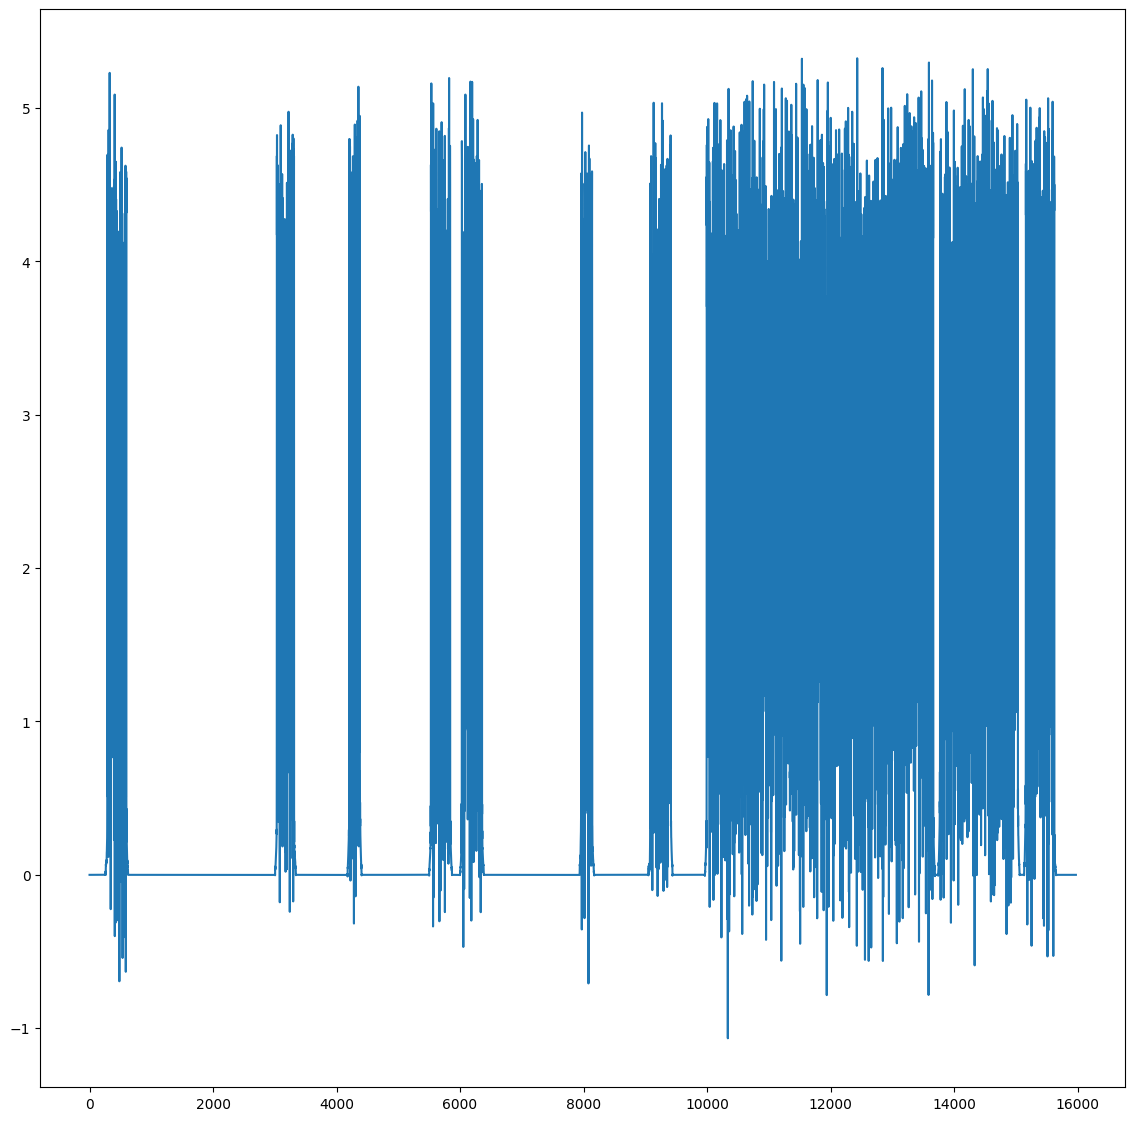

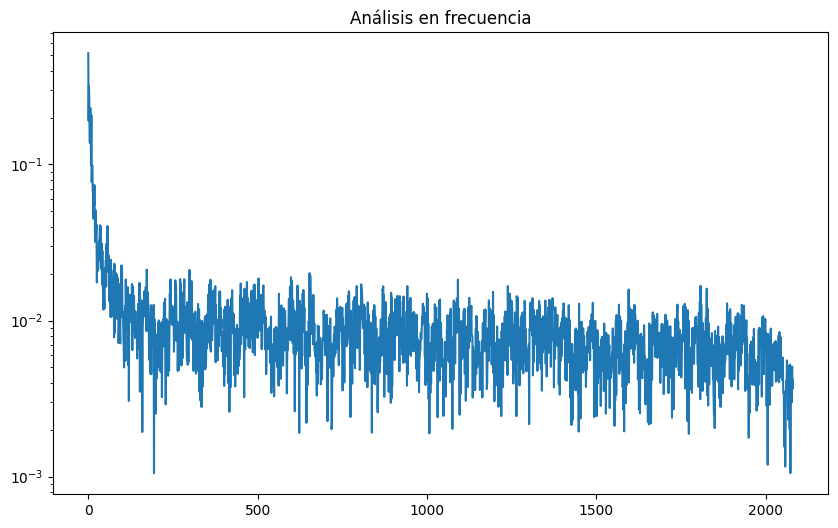

In [ ]:
# Resampleo
yre = signal.resample_poly(datafinal,52,125)      #) Aplicacion de la funcion
fs=4160                                           #) Cambio de frecuencia

# Analisis en tiempo
plt.plot(yre)
plt.show()

# Analisis en frecuencia
plot_frec(yre,fs,10000,4096)

Armado de la Matriz, para ello es necesario la funcion "reshape" de la biblioteca Numpy. Dicha funcion recibe una señal en una dimension y la estructura de la matriz, esta se conformara de filas, las cuales son el doble de la duracion de la señal, y de las columnas, 2080, esto se debe a que cada linea tiene dichos pixeles, y gracias al resampleo en el paso anteior logramos igualar un pixel a una muestra

In [ ]:
# Reshape
rp = np.reshape(yre, ( 40,2080))

ValueError: cannot reshape array of size 15975 into shape (40,2080)

In [ ]:
visualizar_imagen(rp)



> Como se puede observar, se ve todo negro, muy lejano a la visualizacion del planeta Tierra.
Esto es debido a que en el procesamiento de la señal, los maximos y minimos de la señal fueron afectados, por lo tanto es crucuial reescalar la matriz


In [ ]:
# Reescalar imagen
print(np.amax(rp))                              #) Vemos el minimo y maximo de la senial recibida
print(np.amin(rp))                              #) El primer paso a solucionar es que los valores sean enteramente positivos, y que se el minimo sea 0.

normalizando= rp-np.amin(rp)                    #) A la señal recibida se le le resta el minimo, que este al ser negativo camiba su signo.

rpp=normalizando*(255/np.amax(normalizando))    #) Teniendo el minimo en 0 ya podemos multiplicar los valores por la relacion entre 255, que es nuestro valor buscado, y el maximo de la señal pre-normalizada

print(np.amax(rpp))
print(np.amin(rpp))                             #) Corroboramos el minimo y el maximo.


5.6170161740413596
-0.9560657961441832
255.0
0.0


In [ ]:
visualizar_imagen(rpp)

Despues de este proceso logramos ver nuestra primera imagen, la cual se encuentra corrida respecto de sus lineas, con los colores muy oscuros y un poco de ruido, sigamos con el procesamiento de la señal.

In [ ]:
senialNorm1d=rpp.flatten(order= 'C') #) Transformamos nuestra matriz en un vector para trabajar con el

El primer paso de esta segunda etapa es sincronizar la imagen con sus lineas respectivas, para ello elaboramos un vector, que sirva como guia para el reconociemiento del sync, este vector toma los valores teoricos, respetando la grilla 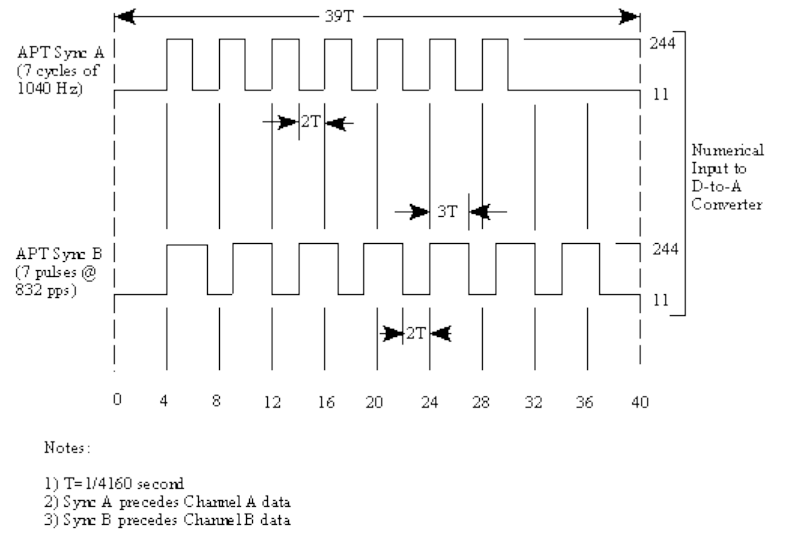

Esto nos ayuda a solucionar el Efecto Doppler, que en este caso ya fue solucionado

In [ ]:
synca=[11,11,11,11,244,244,11,11,244,244,11,11,244,244,11,11,244,244,11,11,244,244,11,11,244,244,11,11,244,244,11,11,11,11,11,11,11,11,11,11]   #) Creamos el vector para el reconociemiento

In [ ]:
idx = obtener_muestras_comienzo_sync(senialNorm1d,synca)   #) Llamamos a la funcion y le pasamos la señal y el vector

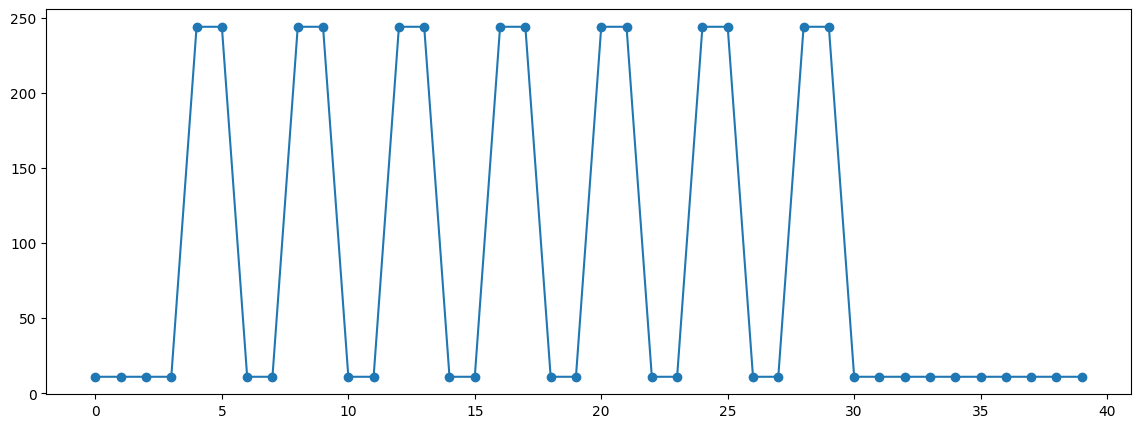

[1605, 3685, 5765, 7845, 9925, 12005, 14085, 16165, 18245, 20325, 22405, 24485, 26565, 28644, 32805, 34884, 36965, 39045, 41125, 43205, 45285, 47365, 49445, 51524, 53605, 55685, 57764, 59844, 61924, 64004, 66084, 68164, 70244, 72324, 74405, 76484, 78564, 80644, 82724, 84804, 86884, 88964, 91044, 93124, 95204, 97284, 99364, 101444, 103524, 105605, 107684, 109765, 111844, 113924, 116004, 118084, 120165, 122604, 124981, 128892, 132645, 134724, 136804, 138888, 140965, 143044, 145124, 147205, 149296, 151364, 153448, 157641, 160388, 163844, 172165, 174245, 176325, 178405, 180485, 182565, 184645, 186725, 188805, 190885, 192965, 195045, 197125, 199205, 201285, 203365, 205445, 207525, 209605, 211685, 213765, 215845, 217925, 220005, 222085, 224165, 226245, 228325, 230405, 232485, 234565, 236645, 238725, 240805, 242885, 244965, 247045, 249125, 251205, 253285, 255365, 257445, 259525, 261605, 263685, 265765]


In [ ]:
#Verificamos el vector de sincronizacion
plt.figure(figsize=(14,5))
plt.plot(synca, 'o-')
plt.show()
print(obtener_muestras_comienzo_sync(yre,synca))

[2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080.
 2079. 4161. 2079. 2081. 2080. 2080. 2080. 2080. 2080. 2080. 2079. 2081.
 2080. 2079. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2081. 2079. 2080.
 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080.
 2081. 2079. 2081. 2079. 2080. 2080. 2080. 2081. 2439. 2377. 3911. 3753.
 2079. 2080. 2084. 2077. 2079. 2080. 2081. 2091. 2068. 2084. 4193. 2747.
 3456. 8321. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080.
 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080.
 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080.
 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080. 2080.    0.]


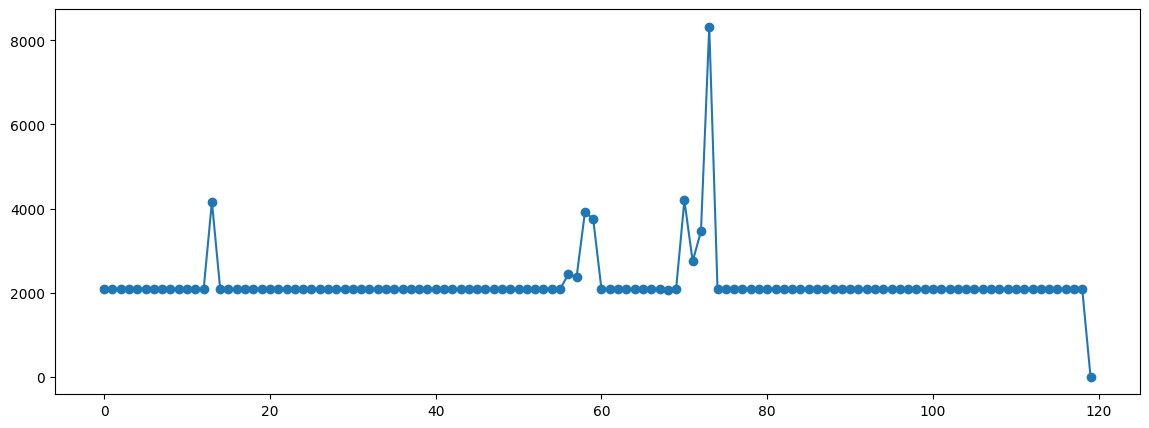

In [ ]:
#)Graficamos las diferencias para notar bien los saltos
dff=np.zeros(len(idx))

for k in range(len(idx)-1):
    dff[k]=np.abs(idx[k]-idx[k+1])
print(dff)

plt.figure(figsize=(14,5))
plt.plot(dff, 'o-')
plt.show()


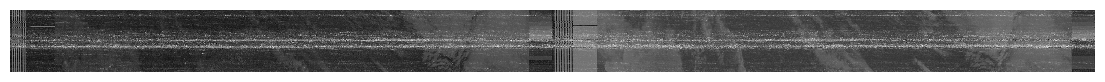

In [ ]:
aptsync=np.concatenate((senialNorm1d[idx[0]:idx[0]+2080],senialNorm1d[idx[1]:idx[1]+2080]))      #) Creamos una variable que concatene las 2 primeras lineas
for k in range(2,len(idx)-1):                                                                    #) Creamos un bucle que recorra, sin contar las primeras dos lineas, el largo del indice menos el ultimo, ya que dicha linea no seria completa
  s=senialNorm1d[idx[k]:idx[k]+2080]                                                             #) Creamos esta variable para que tome el valor del indice y sume 2080 muestras
  aptsync=np.concatenate((aptsync,s))                                                            #) Concatenamos las variables reescribiendola en el proceso
rshsync= np.reshape(aptsync, (len(idx)-1, 2080))                                                 #) Obtenemos un vector 1d y aplicamos reshape para armar la matriz
visualizar_imagen(rshsync)

Obtenemos la imagen ya sincronizada con sus lineas, pero el problema de color prosigue. Para ello tomaremos la informacion que esconde la telemetria.

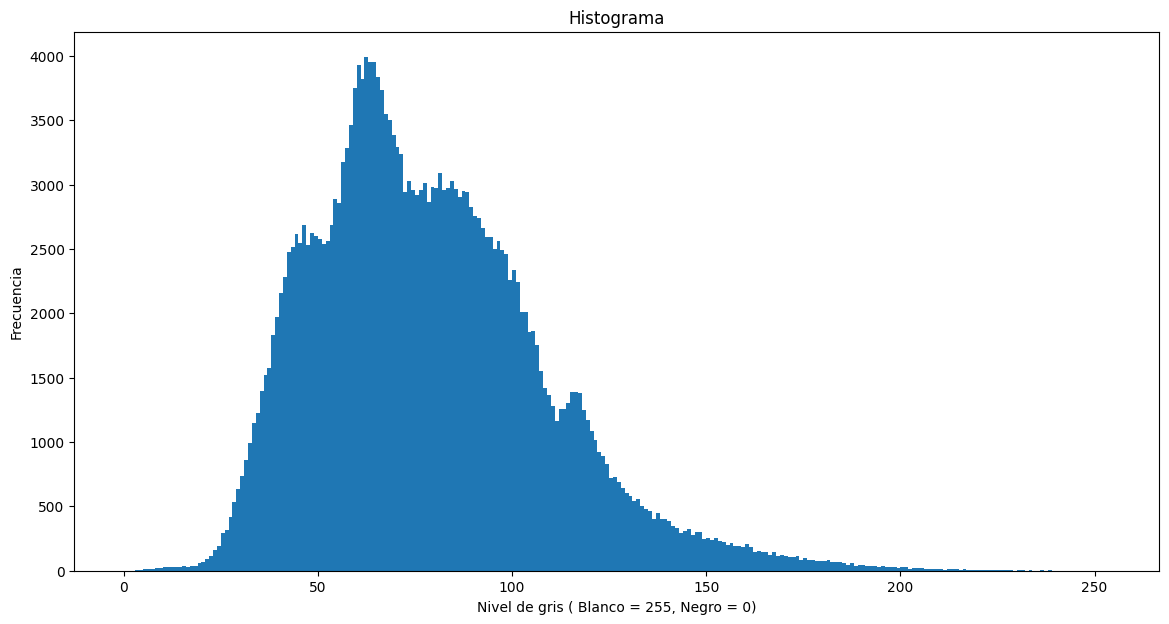

In [ ]:
visualizar_histograma(aptsync)

Como se logra observar en el histograma, los valores no alcanzan los maximos ni los minimos, para solucionar esto vamos a observar las franjas de telemetria

(119, 45)
(119,)


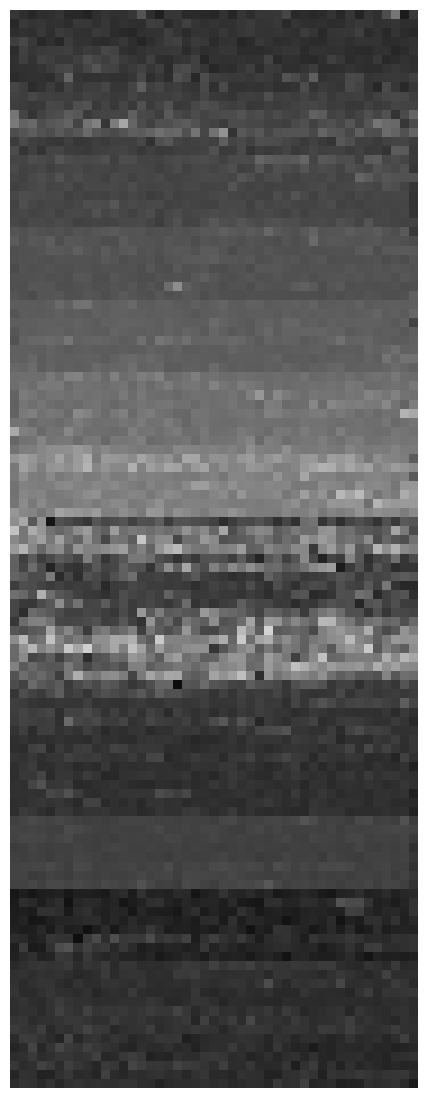

In [ ]:
telcol=rshsync[:,995:1040]           #) Tomamos el valor teorico de donde arranca y termina el telemetry y nos quedamos con toda esa columna-franja
print(telcol.shape)
visualizar_imagen(telcol)
prom=np.mean(telcol, 1)              #) Como necesitamos quedarnos con solo una columna, y para evitar errores en la lectura del telemetry debido al ruido, hacemos un promedio de dichas columnas utilizando mean de numpy
print(prom.shape)
visualizar_imagen(prom)

"Para solucionar esto, y recuperar los niveles del sensor AVHRR, la señal APT en el cuadro de telemetría envía valores conocidos para permitir una calibración. La siguiente tabla muestra como se compone el cuadro de telemetría y los valores de calibración, la cual se compone de 16 "wedges". A su vez cada wedge se repite en 8 filas y 45 columnas consecutivas."

![texto alternativo](https://iie.fing.edu.uy/~gbelcredi/tallerineImSat/fig/wedges.png)

Como cada wedge tiene un valor asignado y cada uno tiene un tamaño de 8 pixeles creamos un vector con dichos valores para el reconocimiento de este

In [ ]:
hh=[31,31,31,31,31,31,31,31,63,63,63,63,63,63,63,63,95,95,95,95,95,95,95,95,127,127,127,127,127,127,127,127,159,159,159,159,159,159,159,159,191,191,191,191,191,191,191,191,223,223,223,223,223,223,223,223,255,255,255,255,255,255,255,255,0,0,0,0,0,0,0,0,]   #) Creamos el vector de sincronizacion del telemetry con los valores del digital value

In [ ]:
idxtel, sim = obtener_indices_comienzo_telemetria_con_similitud(prom, hh)    #) Creamos dos variables que guarden la informacion requerida, indice y similitud

In [ ]:
print(idxtel)
print(sim)

print(np.max(sim))              #) Llamamos a la similitud mas grande con la funcion max de numpy

sim.index(np.max(sim))          #) Buscamos que lugar ocupa dentro del indice con la funcion index

[10]
[106637.22937724323]
106637.22937724323


0

In [ ]:
nv=prom[idxtel[sim.index(np.max(sim))]:idxtel[sim.index(np.max(sim))] +72] #) Nos quedamos con la telemetria mas similar, el 72 nace de los wedges, 9 valores, cada valor 8 pixeles
print(nv)
print(np.max(nv))
print(np.min(nv))

[ 65.32823148  74.75849879  85.23724937  88.89288834  66.81023576
  64.26866501  76.90768342  71.88451517  73.87061122  70.70737995
  69.63706122  70.63596854  70.8078965   73.68478779  85.24705386
  84.12359588  85.12295785  83.24910773  82.44410754  82.74326173
  84.89992785  82.3735187   95.55231944  93.77037405  95.39066719
  95.68071174 100.13285172  95.23098775  97.32802584  98.6422399
 112.74478817 113.93054759 116.24670178 114.96295509 118.98498003
 112.88872866 116.74752379 116.8619537  128.36392624 144.57285673
 148.10883937 128.40247125 132.82823482 135.69048924 133.50274309
 135.83562792  77.52812553 121.03742149 117.78130222 132.71665172
  80.06438204  90.56890173  72.59582696  63.9563311   72.23336745
  71.41224522  87.3331797  105.05733838 111.22750232 138.77413134
 132.93244322 118.33749779 124.54689941 120.16388947  75.47237641
  65.70100173  60.04191647  55.82749773  60.46088258  56.07597151
  50.33430101  53.43417071]
148.10883936713734
50.33430101104044


Para calibrar la imagen buscamos ahora una operación lineal de tipo $aX+ b \to Y$, que transforme el vector de calibración recibido en el vector de calibración original. Una vez obtenidos los valores de $a$ y $b$, aplicamos la transformación a todos los elementros de la matriz APT, es decir:
$\mathcal{I}_{apt~cal} = a\mathcal{I}_{apt} + b$

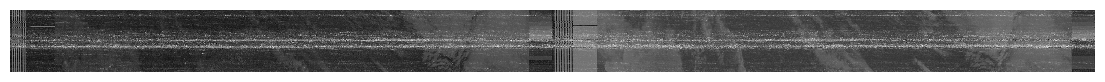

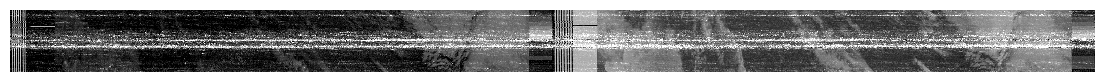

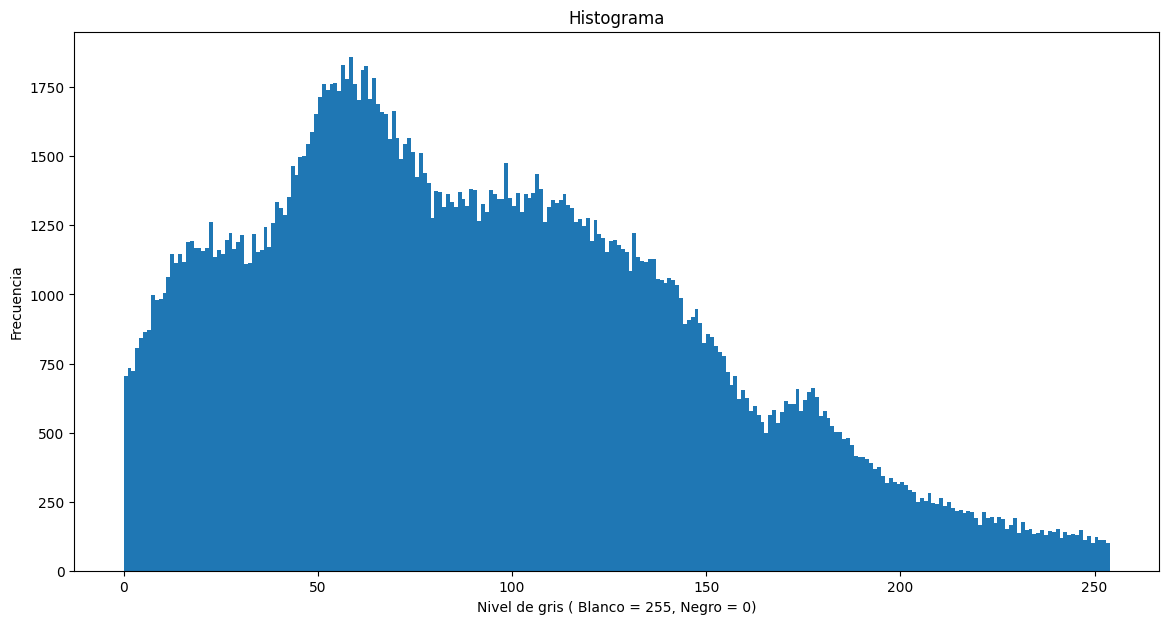

In [ ]:
a, b =np.polyfit(nv,hh,1)         #) Creo las avariables a y b que reciben lo que nos da la funcion polyfit, a la cual le ingresamos la mayor similitud y el vector de valores teoricos, seguido el grado de la funcion, de primer grado
aptcal=a*rshsync+b                #) Planteo la ecuacion proporcionada

visualizar_imagen(rshsync)        #) Imagen antes de calibrar
visualizar_imagen(aptcal)         #) Imagen calibrada

h=aptcal.flatten(order= 'C')      #) Transformo la matriz en un vector para visualizar su histograma
visualizar_histograma(h)